In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# ── RUTAS ─────────────────────────────────────────────────────────
BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")
CSV_ROOT = BASE / "CSV" / "CSV"

assert CSV_ROOT.exists(), f"No se encontró la carpeta: {CSV_ROOT}"

# ── FEATURES (39 columnas del dataset) ───────────────────────────
FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

# ── GRUPOS POR CAPA OSI ───────────────────────────────────────────
GRUPOS_OSI = {
    'Capa 2 — Enlace':       ['ARP', 'LLC'],
    'Capa 3 — Red':          ['Protocol Type', 'Time_To_Live', 'ICMP', 'IGMP', 'IPv'],
    'Capa 4 — Transporte':   ['TCP', 'UDP', 'Header_Length',
                              'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
                              'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
                              'cwr_flag_number', 'ack_count', 'syn_count',
                              'fin_count', 'rst_count'],
    'Capa 7 — Aplicación':   ['HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
                              'SSH', 'IRC', 'DHCP'],
    'Estadísticas de Flujo': ['Rate', 'Tot sum', 'Min', 'Max', 'AVG',
                              'Std', 'Tot size', 'IAT', 'Number', 'Variance'],
}

# Validar que GRUPOS_OSI cubre exactamente las 39 features
_features_en_grupos = [f for feats in GRUPOS_OSI.values() for f in feats]
_faltantes  = set(FEATURES) - set(_features_en_grupos)
_sobrantes  = set(_features_en_grupos) - set(FEATURES)
assert not _faltantes, f"Features sin grupo: {_faltantes}"
assert not _sobrantes, f"Features en grupo que no existen: {_sobrantes}"

# ── MAPEAR ESTRUCTURA DE CARPETAS → CATÁLOGO ──────────────────────
catalogo = {}

for carpeta in sorted(CSV_ROOT.iterdir()):
    if not carpeta.is_dir():
        continue
    archivos = sorted(carpeta.glob("*.csv"))
    if not archivos:
        continue
    size_mb = sum(f.stat().st_size for f in archivos) / (1024 ** 2)
    catalogo[carpeta.name] = {
        'archivos':   archivos,
        'n_archivos': len(archivos),
        'size_mb':    round(size_mb, 2),
        'tipo':       'benigno' if 'Benign' in carpeta.name else 'ataque',
    }

# ── REFERENCIAS RÁPIDAS ───────────────────────────────────────────
CLASE_BENIGNA = 'Benign_Final'
CLASES_ATAQUE = sorted([k for k in catalogo if k != CLASE_BENIGNA])

assert CLASE_BENIGNA in catalogo, f"No se encontró la clase benigna: {CLASE_BENIGNA}"

# ── TABLA RESUMEN ─────────────────────────────────────────────────
df_catalogo = pd.DataFrame([
    {'clase': k, 'tipo': v['tipo'], 'n_archivos': v['n_archivos'], 'size_mb': v['size_mb']}
    for k, v in catalogo.items()
]).sort_values('size_mb', ascending=False).reset_index(drop=True)

# ── RESUMEN EN CONSOLA ────────────────────────────────────────────
total_mb      = df_catalogo['size_mb'].sum()
total_archivos = df_catalogo['n_archivos'].sum()

print("=" * 65)
print("  DATASET CICIoT2023 — Estructura cargada")
print("=" * 65)
print(f"  Ruta:         {CSV_ROOT}")
print(f"  Clases:       {len(catalogo)}  ({len(CLASES_ATAQUE)} ataques + 1 benigno)")
print(f"  Archivos CSV: {total_archivos}")
print(f"  Tamaño total: {total_mb/1024:.2f} GB  ({total_mb:.0f} MB)")
print(f"  Features:     {len(FEATURES)}  ✓ todas asignadas a un grupo OSI")
print()
print(df_catalogo.to_string(index=False))
print()
print("Variables disponibles:")
print("  catalogo      → dict  clase → {archivos, n_archivos, size_mb, tipo}")
print("  CLASE_BENIGNA → str   'Benign_Final'")
print("  CLASES_ATAQUE → list  33 tipos de ataque (ordenados)")
print("  df_catalogo   → DataFrame resumen del dataset")
print("  FEATURES      → list  39 columnas del dataset")
print("  GRUPOS_OSI    → dict  features por capa (validado)")
print("  BASE/CSV_ROOT → Path  rutas del proyecto")


  DATASET CICIoT2023 — Estructura cargada
  Ruta:         C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\CSV\CSV
  Clases:       34  (33 ataques + 1 benigno)
  Archivos CSV: 309
  Tamaño total: 8.33 GB  (8529 MB)
  Features:     39  ✓ todas asignadas a un grupo OSI

                  clase    tipo  n_archivos  size_mb
        DDoS-ICMP_Flood  ataque          27  1264.83
         DDoS-UDP_Flood  ataque          21   977.51
         DDoS-TCP_Flood  ataque          18   804.74
         DDoS-SYN_Flood  ataque          16   738.44
      DDoS-PSHACK_FLOOD  ataque          16   733.91
       DDoS-RSTFINFLOOD  ataque          16   731.47
DDoS-SynonymousIP_Flood  ataque          14   643.38
          DoS-UDP_Flood  ataque          17   577.35
          DoS-TCP_Flood  ataque          11   481.94
          DoS-SYN_Flood  ataque           8   372.51
           Benign_Final benigno           4   216.88
     Mirai-greeth_flood  ataque          29   191.36
         Mirai-udpplain  ata

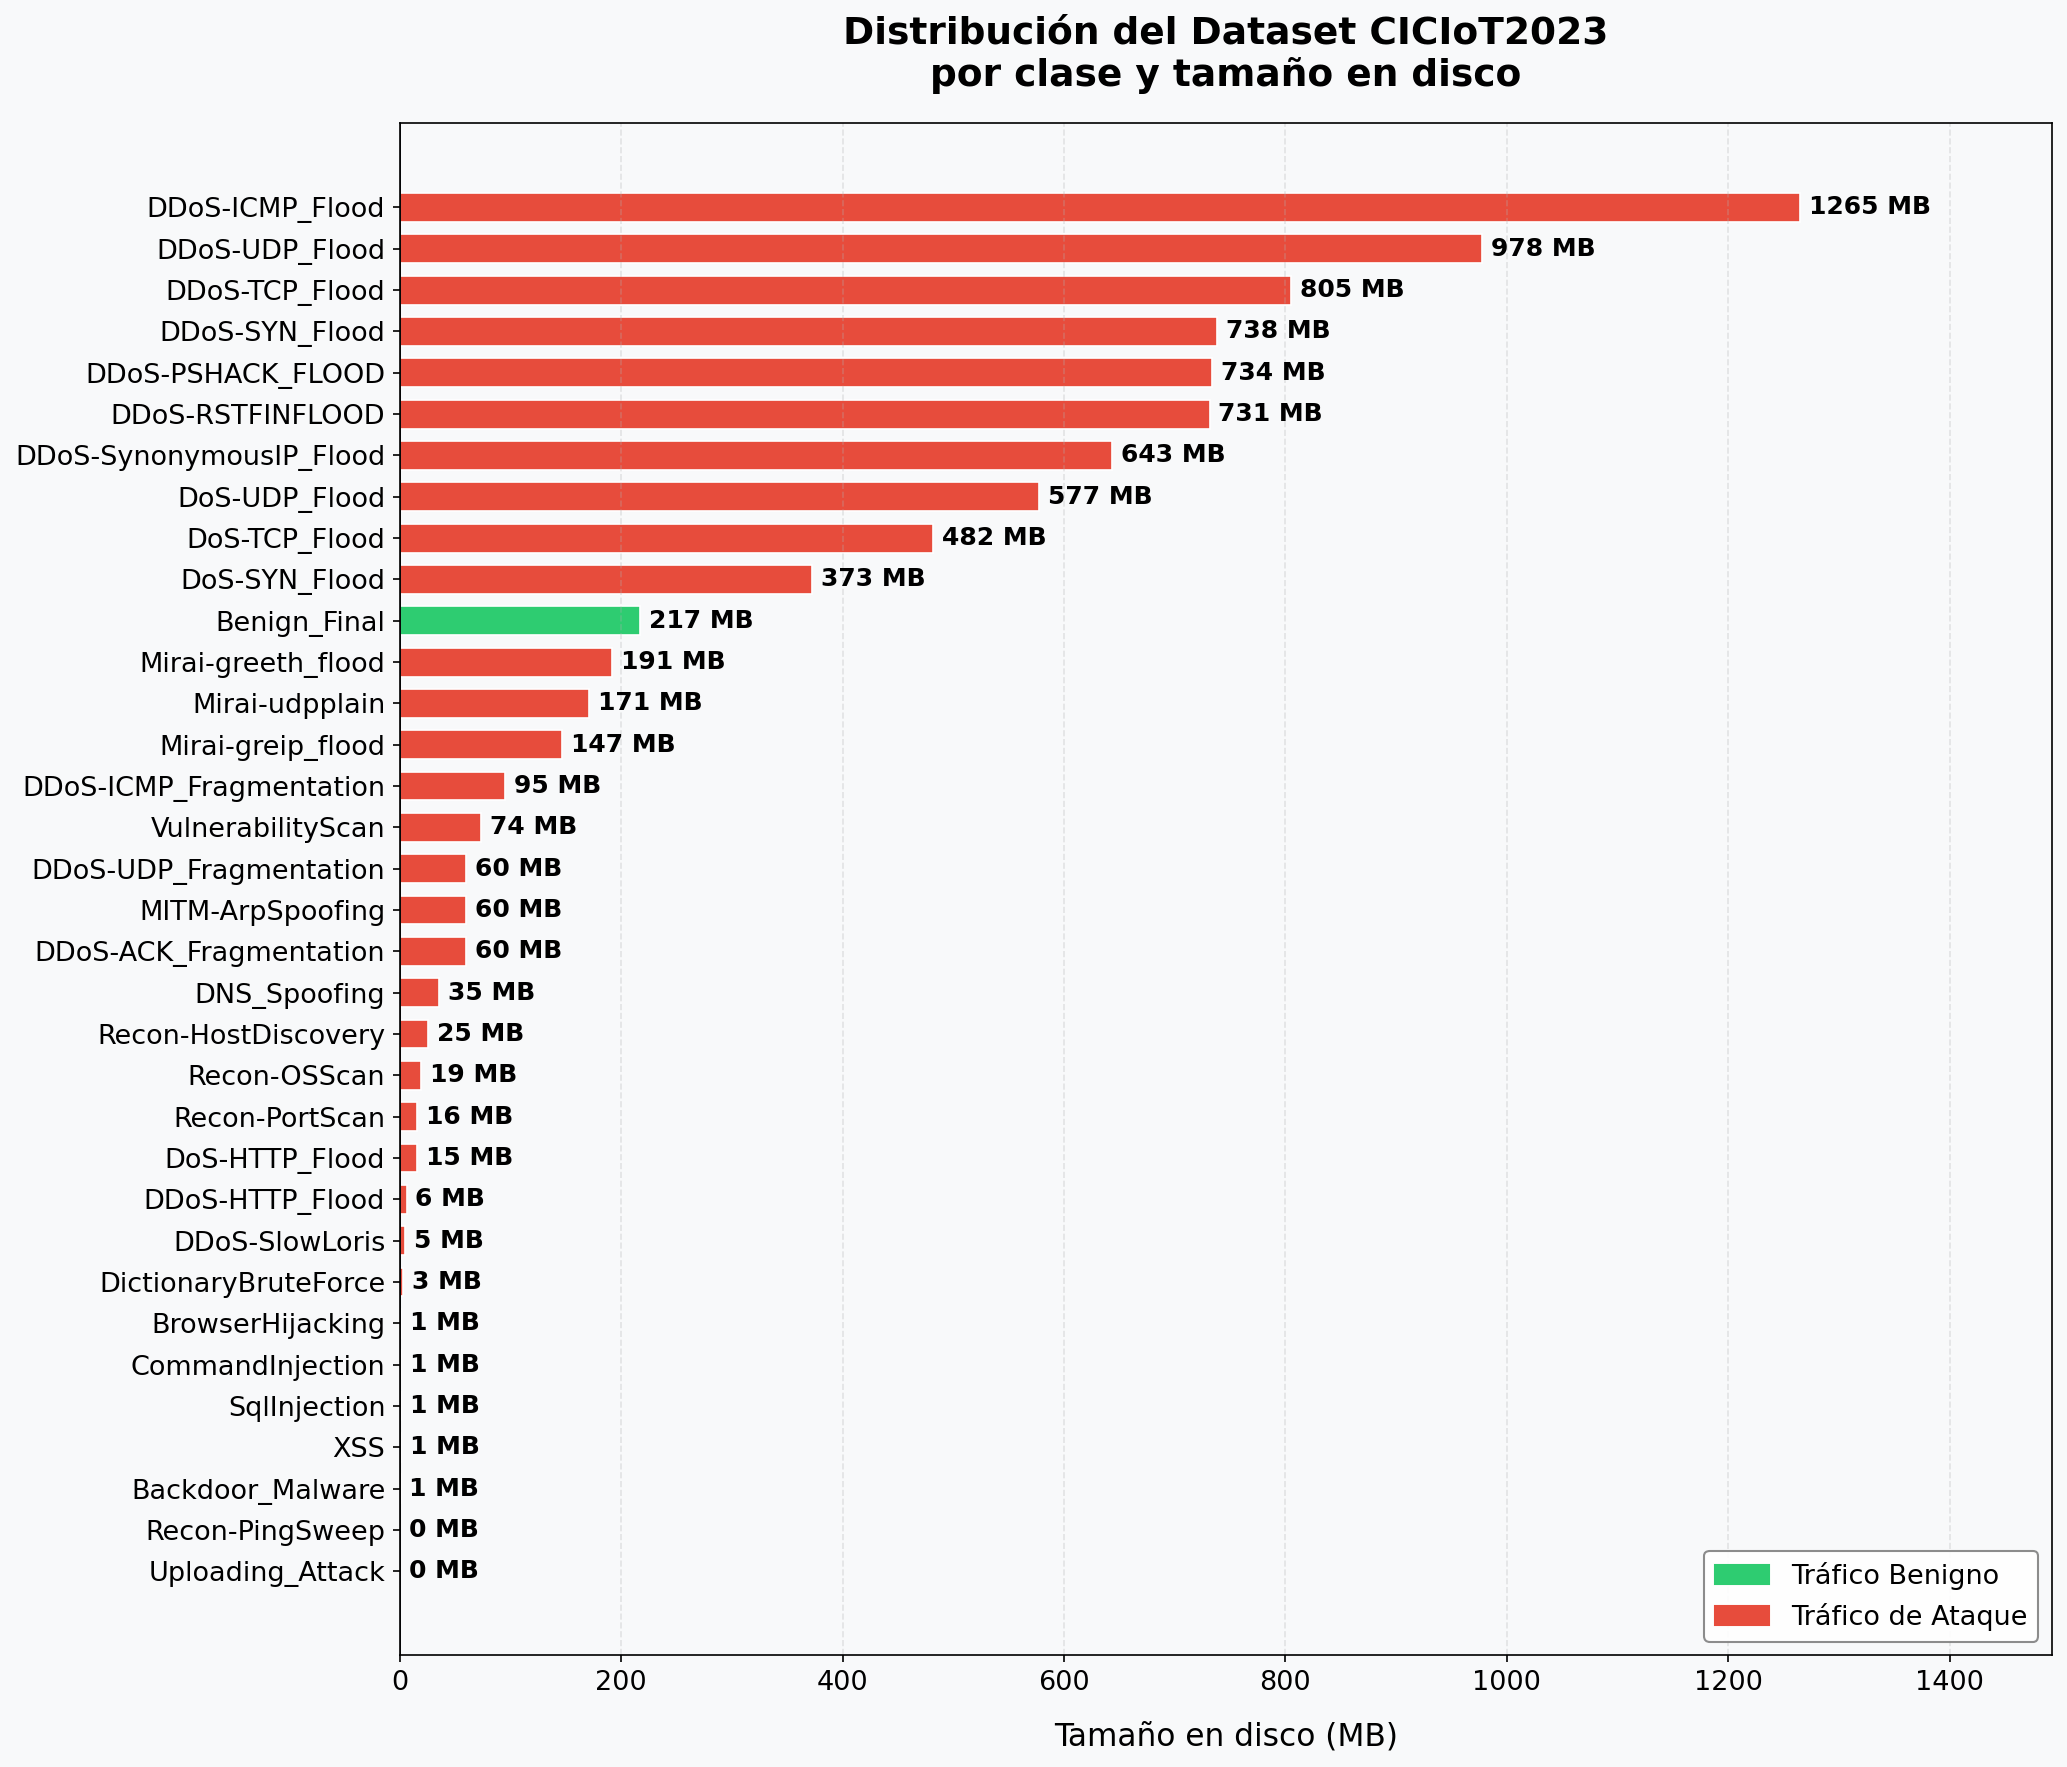

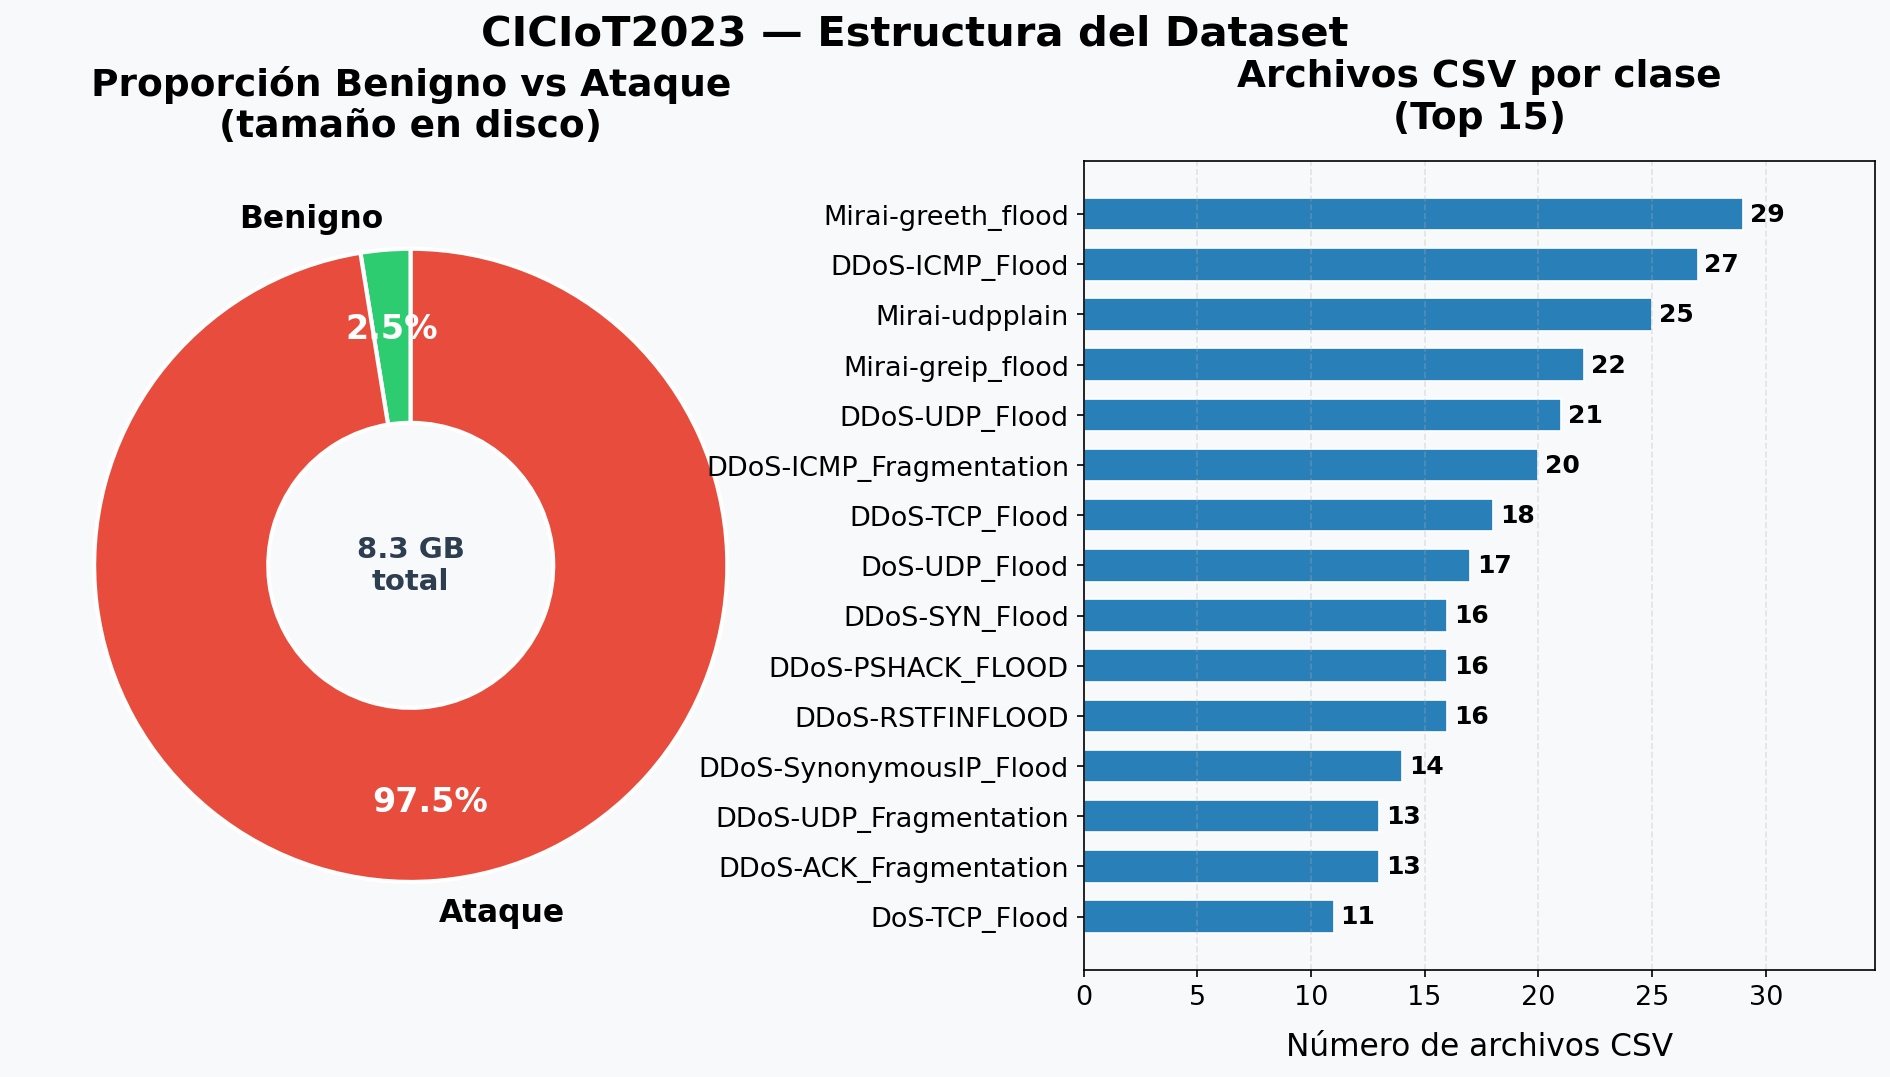

C:\Users\Daniel\AppData\Local\Temp\ipykernel_23276\2186219148.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(grupos, fontsize=13)


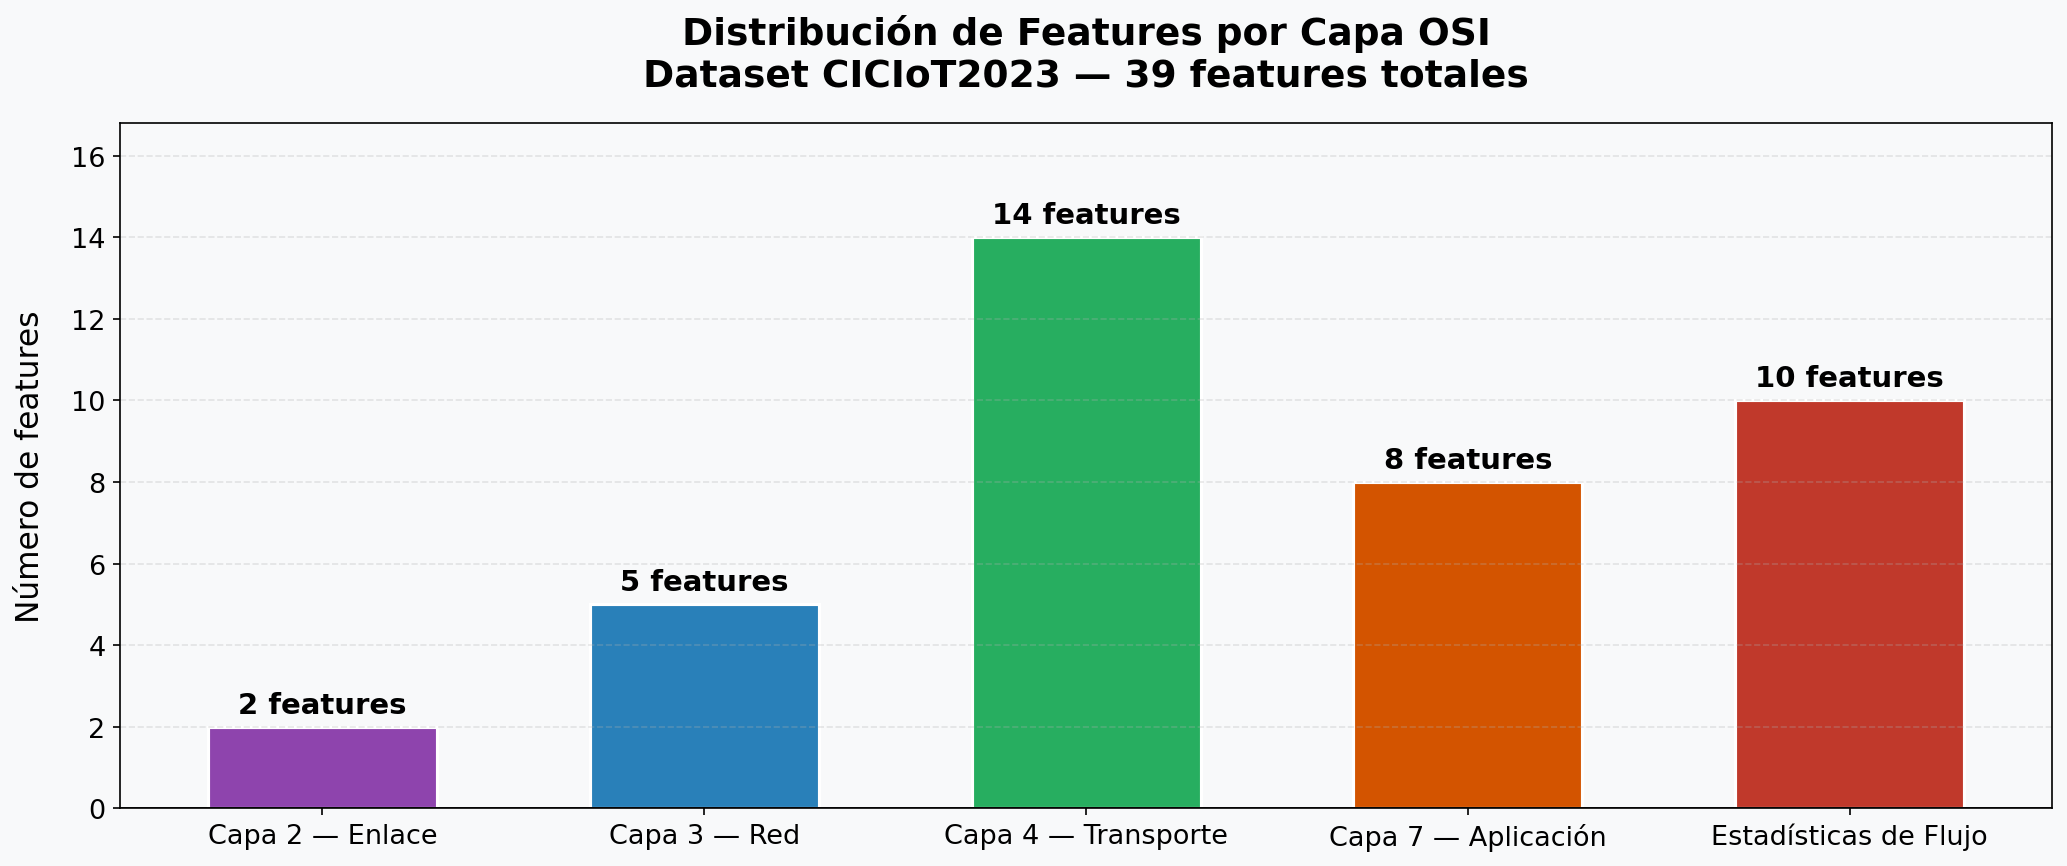

Gráficas guardadas:
  C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\reporte_clases.png
  C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\reporte_proporcion.png
  C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\reporte_features_osi.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── CONFIGURACIÓN GLOBAL DE FUENTES ──────────────────────────────
plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   18,
    'axes.labelsize':   15,
    'xtick.labelsize':  13,
    'ytick.labelsize':  13,
    'legend.fontsize':  13,
    'figure.dpi':       150,
})

PALETA = {
    'benigno':  '#2ecc71',
    'ataque':   '#e74c3c',
    'azul':     '#2980b9',
    'morado':   '#8e44ad',
    'naranja':  '#e67e22',
    'fondo':    '#f8f9fa',
}

COLORES_GRUPO = {
    'Capa 2 — Enlace':       '#8e44ad',
    'Capa 3 — Red':          '#2980b9',
    'Capa 4 — Transporte':   '#27ae60',
    'Capa 7 — Aplicación':   '#d35400',
    'Estadísticas de Flujo': '#c0392b',
}

# ════════════════════════════════════════════════════════════════
# GRÁFICA 1 — Distribución de clases por tamaño en disco
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(PALETA['fondo'])
ax.set_facecolor(PALETA['fondo'])

colores = [PALETA['benigno'] if t == 'benigno' else PALETA['ataque']
           for t in df_catalogo['tipo']]

bars = ax.barh(df_catalogo['clase'], df_catalogo['size_mb'],
               color=colores, edgecolor='white', linewidth=0.8, height=0.7)

for bar, val in zip(bars, df_catalogo['size_mb']):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} MB', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Tamaño en disco (MB)', labelpad=12)
ax.set_title('Distribución del Dataset CICIoT2023\npor clase y tamaño en disco',
             fontweight='bold', pad=18)
ax.set_xlim(0, df_catalogo['size_mb'].max() * 1.18)
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()

leyenda = [
    mpatches.Patch(color=PALETA['benigno'], label='Tráfico Benigno'),
    mpatches.Patch(color=PALETA['ataque'],  label='Tráfico de Ataque'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=13,
          framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.savefig(BASE / 'reporte_clases.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# GRÁFICA 2 — Proporción benigno vs ataque + archivos por clase
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor(PALETA['fondo'])
gs  = GridSpec(1, 2, figure=fig, wspace=0.35)

# — Donut benigno vs ataque —
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(PALETA['fondo'])

mb_benigno = df_catalogo[df_catalogo['tipo'] == 'benigno']['size_mb'].sum()
mb_ataque  = df_catalogo[df_catalogo['tipo'] == 'ataque' ]['size_mb'].sum()
total_mb   = mb_benigno + mb_ataque

wedges, texts, autotexts = ax1.pie(
    [mb_benigno, mb_ataque],
    labels=['Benigno', 'Ataque'],
    colors=[PALETA['benigno'], PALETA['ataque']],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 15, 'fontweight': 'bold'},
)
for at in autotexts:
    at.set_fontsize(16)
    at.set_fontweight('bold')
    at.set_color('white')

ax1.text(0, 0, f'{total_mb/1024:.1f} GB\ntotal',
         ha='center', va='center', fontsize=14, fontweight='bold', color='#2c3e50')
ax1.set_title('Proporción Benigno vs Ataque\n(tamaño en disco)',
              fontweight='bold', pad=16)

# — Barras: archivos por clase (top 15) —
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(PALETA['fondo'])

top15 = df_catalogo.nlargest(15, 'n_archivos')
colores2 = [PALETA['benigno'] if t == 'benigno' else PALETA['azul']
            for t in top15['tipo']]

bars2 = ax2.barh(top15['clase'], top15['n_archivos'],
                 color=colores2, edgecolor='white', linewidth=0.8, height=0.65)

for bar, val in zip(bars2, top15['n_archivos']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=12, fontweight='bold')

ax2.set_xlabel('Número de archivos CSV', labelpad=10)
ax2.set_title('Archivos CSV por clase\n(Top 15)', fontweight='bold', pad=16)
ax2.set_xlim(0, top15['n_archivos'].max() * 1.2)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.invert_yaxis()

plt.suptitle('CICIoT2023 — Estructura del Dataset',
             fontsize=20, fontweight='bold', y=1.02)
plt.savefig(BASE / 'reporte_proporcion.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# GRÁFICA 3 — Features agrupadas por capa OSI
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(PALETA['fondo'])
ax.set_facecolor(PALETA['fondo'])

grupos  = list(GRUPOS_OSI.keys())
conteos = [len(v) for v in GRUPOS_OSI.values()]
colores3 = [COLORES_GRUPO[g] for g in grupos]

bars3 = ax.bar(grupos, conteos, color=colores3,
               edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars3, conteos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val} features', ha='center', va='bottom',
            fontsize=14, fontweight='bold')

ax.set_ylabel('Número de features', labelpad=12)
ax.set_title('Distribución de Features por Capa OSI\nDataset CICIoT2023 — 39 features totales',
             fontweight='bold', pad=18)
ax.set_ylim(0, max(conteos) * 1.2)
ax.set_xticklabels(grupos, fontsize=13)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(BASE / 'reporte_features_osi.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráficas guardadas:")
print(f"  {BASE / 'reporte_clases.png'}")
print(f"  {BASE / 'reporte_proporcion.png'}")
print(f"  {BASE / 'reporte_features_osi.png'}")


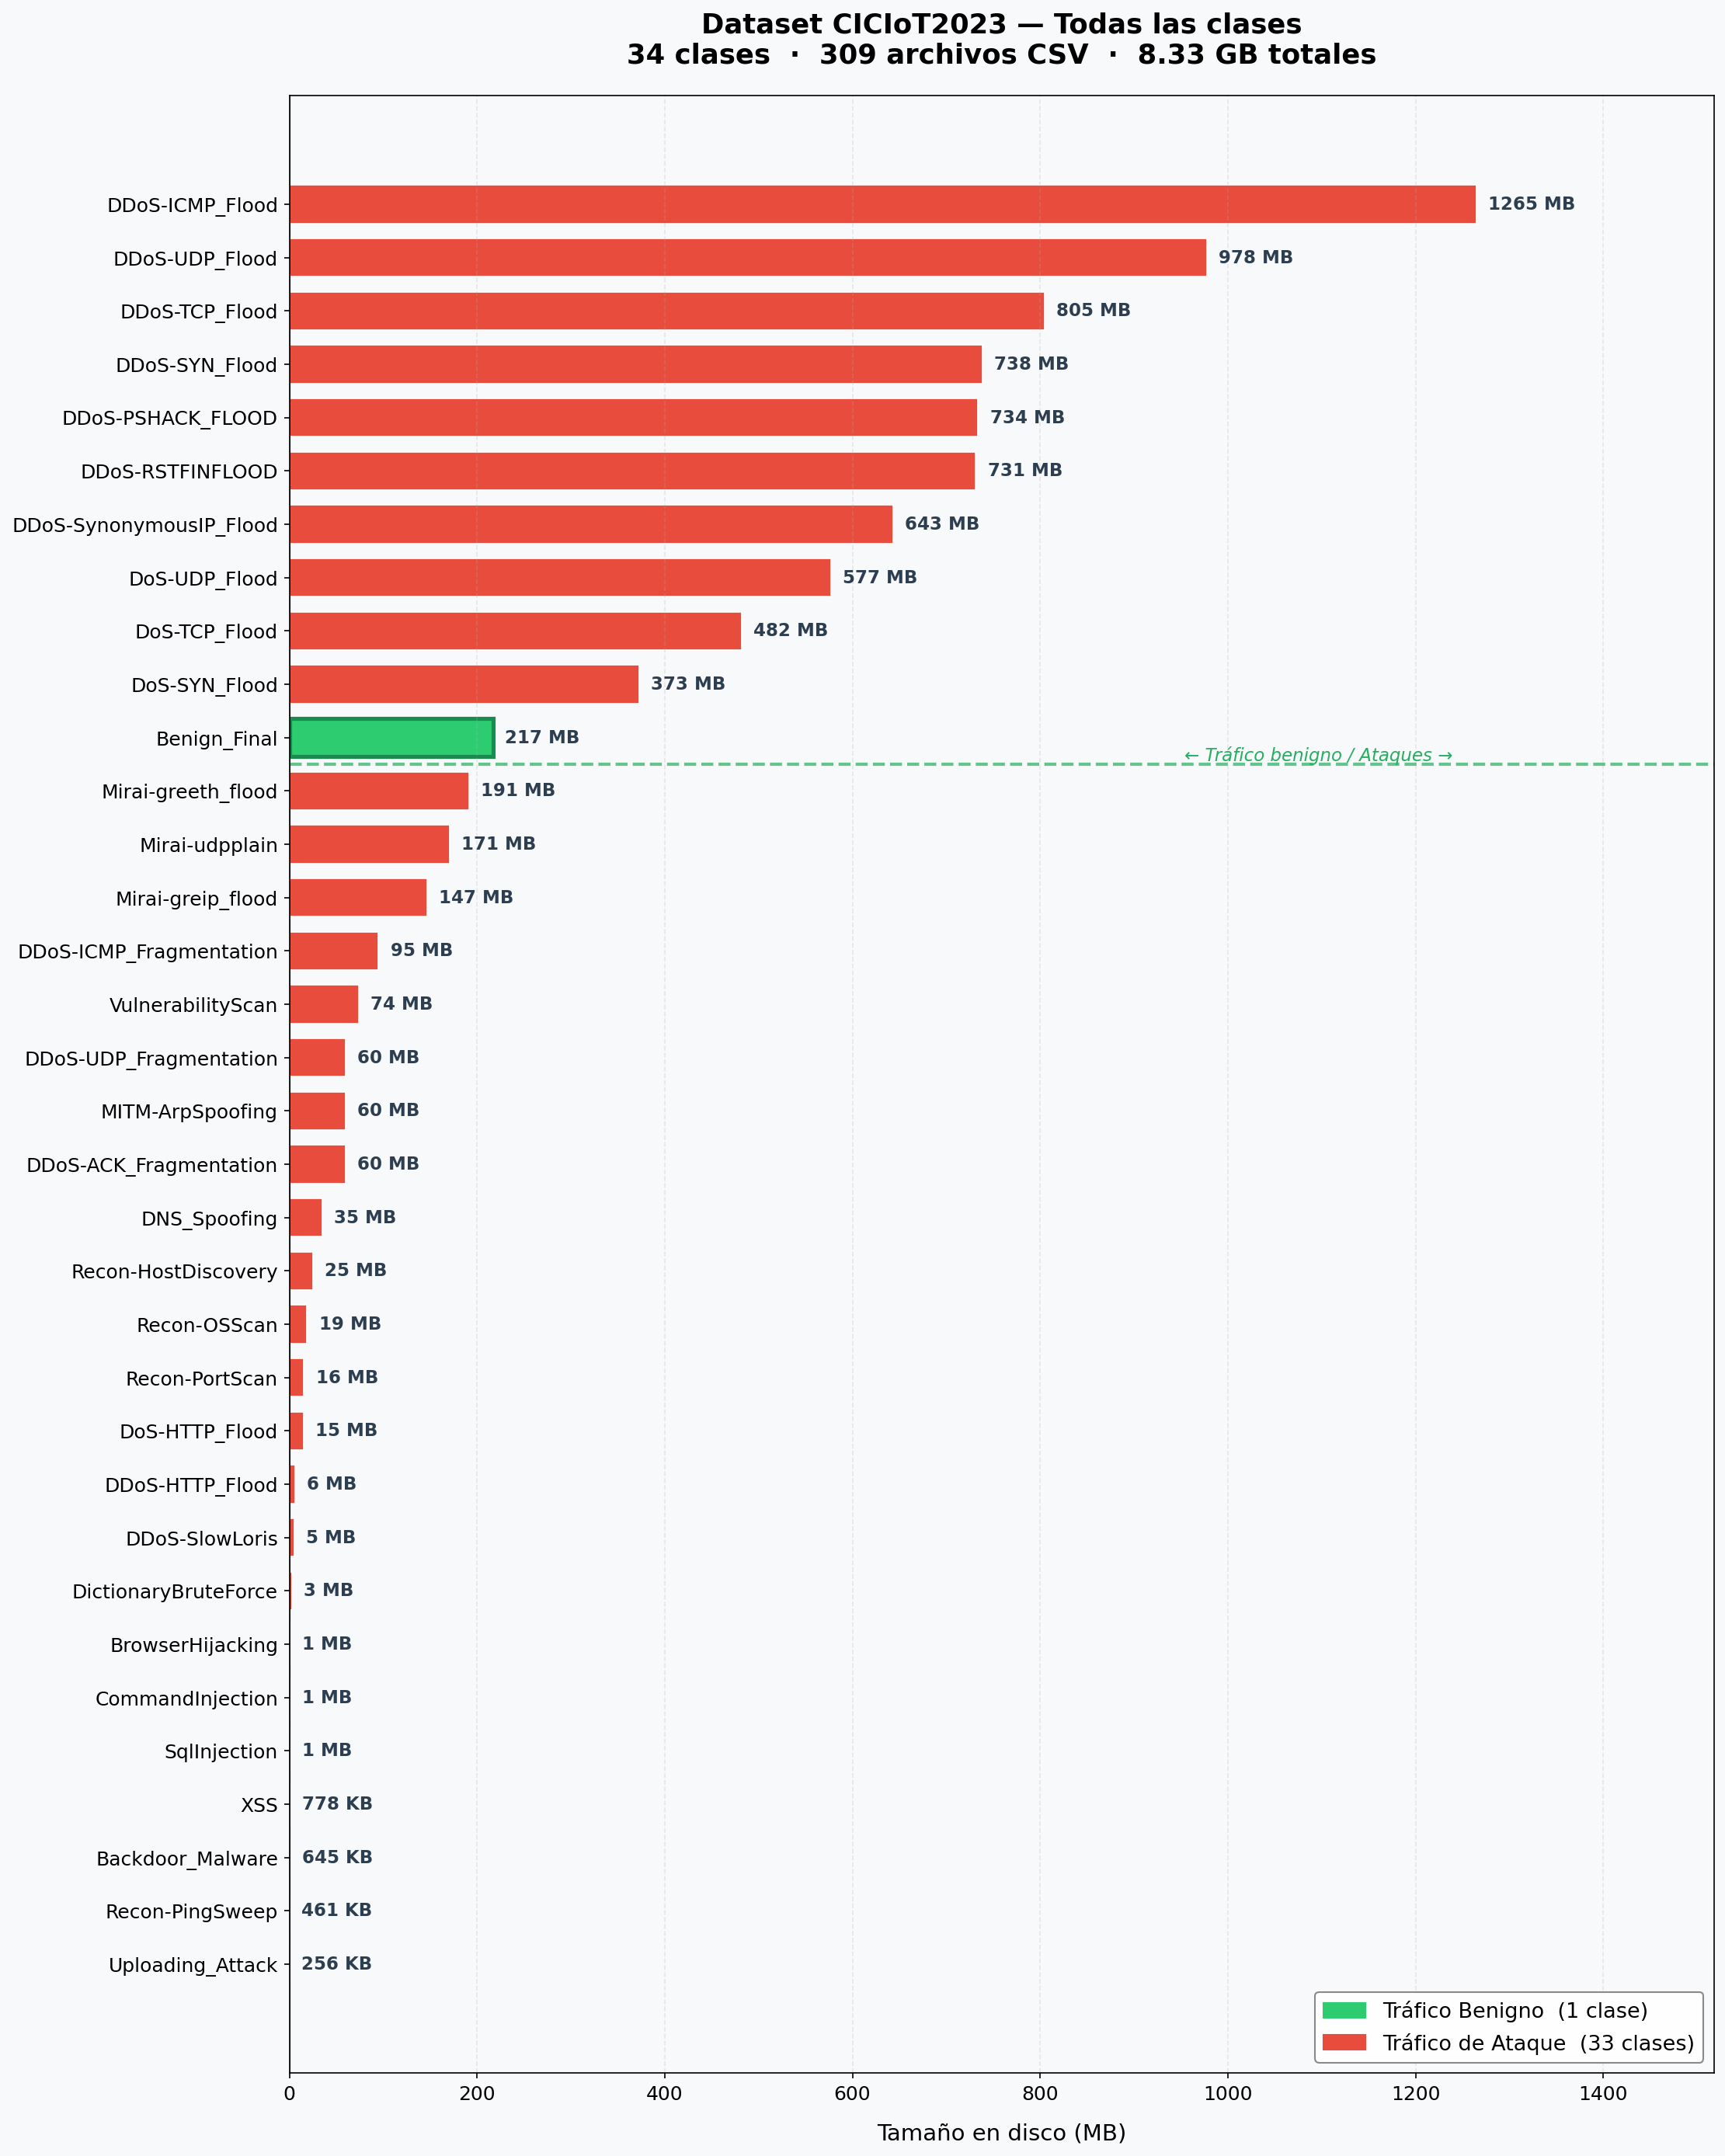

Gráfica guardada en: C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\reporte_todas_clases.png


In [3]:
#-------------GRAFICACIÓN DE CLASES -------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── CONFIGURACIÓN GLOBAL ──────────────────────────────────────────
plt.rcParams.update({
    'font.size':        13,
    'axes.titlesize':   17,
    'axes.labelsize':   14,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  13,
    'figure.dpi':       150,
})

PALETA = {
    'benigno': '#2ecc71',
    'ataque':  '#e74c3c',
    'fondo':   '#f8f9fa',
    'texto':   '#2c3e50',
}

# ════════════════════════════════════════════════════════════════
# GRÁFICA — Todas las clases, ordenadas por tamaño en disco
# ════════════════════════════════════════════════════════════════

# Ordenar: benigno siempre al final para que destaque
df_sorted = df_catalogo.sort_values('size_mb', ascending=True).reset_index(drop=True)

n = len(df_sorted)
fig_height = max(14, n * 0.55)   # altura dinámica según número de clases

fig, ax = plt.subplots(figsize=(15, fig_height))
fig.patch.set_facecolor(PALETA['fondo'])
ax.set_facecolor(PALETA['fondo'])

# Colores por tipo
colores = [PALETA['benigno'] if t == 'benigno' else PALETA['ataque']
           for t in df_sorted['tipo']]

# Barras horizontales
bars = ax.barh(
    df_sorted['clase'], df_sorted['size_mb'],
    color=colores, edgecolor='white', linewidth=0.8, height=0.72
)

# Etiquetas de valor al final de cada barra
max_val = df_sorted['size_mb'].max()
for bar, val, tipo in zip(bars, df_sorted['size_mb'], df_sorted['tipo']):
    label = f'{val:.0f} MB' if val >= 1 else f'{val*1024:.0f} KB'
    ax.text(
        bar.get_width() + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center', fontsize=11, fontweight='bold',
        color=PALETA['texto']
    )

# Línea divisoria entre ataques y benigno
# Benigno es el único de su tipo, marcamos su posición
idx_benigno = df_sorted[df_sorted['tipo'] == 'benigno'].index[0]
ax.axhline(y=idx_benigno - 0.5, color='#27ae60', linewidth=2,
           linestyle='--', alpha=0.7)

# Anotación de separador
ax.text(
    max_val * 0.98, idx_benigno - 0.5,
    '← Tráfico benigno / Ataques →',
    va='bottom', ha='right', fontsize=11,
    color='#27ae60', fontstyle='italic'
)

# Decoración
ax.set_xlabel('Tamaño en disco (MB)', labelpad=12)
ax.set_title(
    'Dataset CICIoT2023 — Todas las clases\n'
    f'34 clases  ·  309 archivos CSV  ·  8.33 GB totales',
    fontweight='bold', pad=20
)
ax.set_xlim(0, max_val * 1.20)
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.25, linestyle='--')

# Leyenda
leyenda = [
    mpatches.Patch(color=PALETA['benigno'], label='Tráfico Benigno  (1 clase)'),
    mpatches.Patch(color=PALETA['ataque'],  label='Tráfico de Ataque  (33 clases)'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=13,
          framealpha=0.92, edgecolor='gray')

# Resaltar la barra benigna con borde grueso
for bar, tipo in zip(bars, df_sorted['tipo']):
    if tipo == 'benigno':
        bar.set_edgecolor('#1a8a50')
        bar.set_linewidth(2.5)

plt.tight_layout()
out_path = BASE / 'reporte_todas_clases.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Gráfica guardada en: {out_path}")

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

# ── REQUIERE: Notebook 1 ejecutado (catalogo, FEATURES, BASE, CLASE_BENIGNA)

# ── RUTAS DE SALIDA ───────────────────────────────────────────────
OUT_DIR = BASE / "particiones"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PATH_BENIGN_FULL  = OUT_DIR / "benign_full.csv"
PATH_BENIGN_TRAIN = OUT_DIR / "benign_train_80.csv"

# ── CARGAR TODOS LOS CSVs BENIGNOS ───────────────────────────────
print("=" * 65)
print("  Cargando archivos benignos...")
print("=" * 65)

archivos_benignos = catalogo[CLASE_BENIGNA]['archivos']
chunks = []

for i, archivo in enumerate(archivos_benignos, 1):
    print(f"  [{i}/{len(archivos_benignos)}] {archivo.name} ...", end=" ")
    df_chunk = pd.read_csv(archivo, usecols=lambda c: c in FEATURES)

    # Asegurar que solo estén las columnas correctas en orden
    cols_presentes = [f for f in FEATURES if f in df_chunk.columns]
    df_chunk = df_chunk[cols_presentes]

    print(f"{len(df_chunk):,} filas  |  {len(cols_presentes)} features")
    chunks.append(df_chunk)

df_benign = pd.concat(chunks, ignore_index=True)

# ── LIMPIEZA BÁSICA ───────────────────────────────────────────────
filas_antes = len(df_benign)
df_benign.replace([np.inf, -np.inf], np.nan, inplace=True)
df_benign.dropna(inplace=True)
filas_despues = len(df_benign)

print()
print(f"  Filas cargadas:   {filas_antes:,}")
print(f"  Filas tras limpiar NaN/Inf: {filas_despues:,}  "
      f"(eliminadas: {filas_antes - filas_despues:,})")

# ── GUARDAR CSV COMPLETO BENIGNO ──────────────────────────────────
df_benign.to_csv(PATH_BENIGN_FULL, index=False)
size_mb = PATH_BENIGN_FULL.stat().st_size / (1024**2)
print(f"\n  ✓ benign_full.csv guardado  →  {filas_despues:,} filas  |  {size_mb:.1f} MB")

# ── PARTICIÓN 80 / 20 ─────────────────────────────────────────────
df_train, df_val = train_test_split(
    df_benign,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# Guardar solo el 80%
df_train.to_csv(PATH_BENIGN_TRAIN, index=False)
size_train_mb = PATH_BENIGN_TRAIN.stat().st_size / (1024**2)

# ── RESUMEN ───────────────────────────────────────────────────────
print()
print("=" * 65)
print("  RESUMEN DE PARTICIÓN")
print("=" * 65)
print(f"  Total benignos:       {filas_despues:,}  (100%)")
print(f"  Train  80%:           {len(df_train):,}  → benign_train_80.csv  ({size_train_mb:.1f} MB)")
print(f"  Val    20%:           {len(df_val):,}  → (en memoria, aún no guardado)")
print()
print(f"  Features:             {df_benign.shape[1]}")
print(f"  Carpeta de salida:    {OUT_DIR}")
print()
print("  Próximo paso:")
print("  → Analizar distribución de malignos para decidir")
print("    cuántos tomar por clase como conjunto de prueba.")
print()

# ── REFERENCIA PARA EL SIGUIENTE NOTEBOOK ─────────────────────────
n_benign_total = filas_despues
n_benign_train = len(df_train)
n_benign_val   = len(df_val)
n_attack_target = n_benign_val  # 20% equivalente de malignos (referencia)

print(f"  Referencia para malignos:")
print(f"  El 20% benigno = {n_benign_val:,} filas")
print(f"  → Ese será el tope de malignos a incluir en prueba")
print(f"     (distribuidos entre las 33 clases de ataque)")

  Cargando archivos benignos...
  [1/4] BenignTraffic.pcap.csv ... 362,361 filas  |  39 features
  [2/4] BenignTraffic1.pcap.csv ... 295,585 filas  |  39 features
  [3/4] BenignTraffic2.pcap.csv ... 310,413 filas  |  39 features
  [4/4] BenignTraffic3.pcap.csv ... 129,832 filas  |  39 features

  Filas cargadas:   1,098,191
  Filas tras limpiar NaN/Inf: 1,098,126  (eliminadas: 65)

  ✓ benign_full.csv guardado  →  1,098,126 filas  |  217.9 MB

  RESUMEN DE PARTICIÓN
  Total benignos:       1,098,126  (100%)
  Train  80%:           878,500  → benign_train_80.csv  (174.3 MB)
  Val    20%:           219,626  → (en memoria, aún no guardado)

  Features:             39
  Carpeta de salida:    C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\particiones

  Próximo paso:
  → Analizar distribución de malignos para decidir
    cuántos tomar por clase como conjunto de prueba.

  Referencia para malignos:
  El 20% benigno = 219,626 filas
  → Ese será el tope de malignos a incluir en

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# ── RUTA ─────────────────────────────────────────────────────────
PART_DIR = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\particiones")

assert PART_DIR.exists(), f"No se encontró: {PART_DIR}"

# ── 1. MAPEAR ARCHIVOS ────────────────────────────────────────────
archivos = sorted(PART_DIR.glob("*.csv"))

print("=" * 60)
print("  CARPETA: particiones/")
print("=" * 60)
for f in archivos:
    size_mb = f.stat().st_size / (1024**2)
    print(f"  {f.name:<30} {size_mb:.2f} MB")
print()

# ── 2. CARGAR Y ANALIZAR CADA ARCHIVO ────────────────────────────
dfs = {}

for archivo in archivos:
    nombre = archivo.stem
    print("=" * 60)
    print(f"  ARCHIVO: {archivo.name}")
    print("=" * 60)

    df = pd.read_csv(archivo)
    dfs[nombre] = df

    print(f"\n  Dimensiones:  {df.shape[0]:,} filas  x  {df.shape[1]} columnas")

    # Tipos de dato
    tipos = df.dtypes.value_counts()
    print(f"  Tipos de dato:")
    for dtype, count in tipos.items():
        print(f"    {str(dtype):<12} → {count} columnas")

    # Valores nulos
    nulos = df.isnull().sum().sum()
    print(f"\n  Valores nulos:  {nulos}")

    # Valores infinitos (solo en columnas numéricas)
    num_cols = df.select_dtypes(include=[np.number]).columns
    infs = np.isinf(df[num_cols].values).sum()
    print(f"  Valores inf:    {infs}")

    # Columnas
    print(f"\n  Columnas ({df.shape[1]}):")
    for i, col in enumerate(df.columns, 1):
        print(f"    {i:02d}. {col}")

    # Primeras filas
    print(f"\n  Primeras 3 filas:")
    print(df.head(3).to_string())

    # Estadísticas básicas
    print(f"\n  Estadísticas (columnas numéricas):")
    print(df.describe().round(4).to_string())
    print()

# ── 3. COMPARAR AMBOS ARCHIVOS ────────────────────────────────────
print("=" * 60)
print("  COMPARACIÓN ENTRE ARCHIVOS")
print("=" * 60)

nombres = list(dfs.keys())
if len(dfs) == 2:
    a, b   = nombres[0], nombres[1]
    df_a, df_b = dfs[a], dfs[b]

    print(f"\n  {'':30} {a:<25} {b}")
    print(f"  {'Filas':<30} {df_a.shape[0]:<25,} {df_b.shape[0]:,}")
    print(f"  {'Columnas':<30} {df_a.shape[1]:<25} {df_b.shape[1]}")
    print(f"  {'Mismas columnas':<30} {list(df_a.columns) == list(df_b.columns)}")

    if list(df_a.columns) == list(df_b.columns):
        diff_filas = df_a.shape[0] - df_b.shape[0]
        pct        = df_b.shape[0] / df_a.shape[0] * 100
        print(f"  {'Diferencia de filas':<30} {diff_filas:,}")
        print(f"  {'Porcentaje del full':<30} {pct:.1f}%")


  CARPETA: particiones/
  benign_full.csv                217.88 MB
  benign_train_80.csv            174.30 MB

  ARCHIVO: benign_full.csv

  Dimensiones:  1,098,126 filas  x  39 columnas
  Tipos de dato:
    float64      → 30 columnas
    int64        → 9 columnas

  Valores nulos:  0
  Valores inf:    0

  Columnas (39):
    01. Header_Length
    02. Protocol Type
    03. Time_To_Live
    04. Rate
    05. fin_flag_number
    06. syn_flag_number
    07. rst_flag_number
    08. psh_flag_number
    09. ack_flag_number
    10. ece_flag_number
    11. cwr_flag_number
    12. ack_count
    13. syn_count
    14. fin_count
    15. rst_count
    16. HTTP
    17. HTTPS
    18. DNS
    19. Telnet
    20. SMTP
    21. SSH
    22. IRC
    23. TCP
    24. UDP
    25. DHCP
    26. ARP
    27. ICMP
    28. IGMP
    29. IPv
    30. LLC
    31. Tot sum
    32. Min
    33. Max
    34. AVG
    35. Std
    36. Tot size
    37. IAT
    38. Number
    39. Variance

  Primeras 3 filas:
   Header_Length  Prot

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

# ════════════════════════════════════════════════════════════════
# CONFIGURACIÓN — ajusta solo estas rutas
# ════════════════════════════════════════════════════════════════
BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")
CSV_ROOT = BASE / "CSV" / "CSV"
PART_DIR = BASE / "particiones"

# Parámetros del split (deben coincidir exactamente con el notebook anterior)
RANDOM_STATE   = 42
VAL_SIZE       = 0.20

# Parámetros del muestreo de malignos
N_MINIMO_CLASE = 500   # mínimo garantizado por clase pequeña

# Features (39 columnas)
FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP',
    'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

# Rutas de salida
PATH_BENIGN_VAL  = PART_DIR / "benign_val_20.csv"
PATH_ATTACK_TEST = PART_DIR / "attack_test.csv"
PATH_TEST_FULL   = PART_DIR / "test_full.csv"

assert PART_DIR.exists(), f"No se encontró: {PART_DIR}"
assert CSV_ROOT.exists(), f"No se encontró: {CSV_ROOT}"

# ════════════════════════════════════════════════════════════════
# PASO 1 — Reconstruir df_val desde benign_full.csv
# ════════════════════════════════════════════════════════════════
print("=" * 65)
print("  PASO 1 — Reconstruyendo val benigno desde disco")
print("=" * 65)

PATH_BENIGN_FULL  = PART_DIR / "benign_full.csv"
PATH_BENIGN_TRAIN = PART_DIR / "benign_train_80.csv"

assert PATH_BENIGN_FULL.exists(),  "No se encontró benign_full.csv"
assert PATH_BENIGN_TRAIN.exists(), "No se encontró benign_train_80.csv"

print(f"  Cargando benign_full.csv ...", end=" ")
df_full = pd.read_csv(PATH_BENIGN_FULL)
print(f"{len(df_full):,} filas")

# Reproducir el split exacto con mismo random_state
df_train, df_val = train_test_split(
    df_full,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

print(f"  Split reproducido:")
print(f"    Train: {len(df_train):,} filas")
print(f"    Val:   {len(df_val):,} filas")

# Verificar que train coincide con el archivo guardado
print(f"\n  Verificando consistencia con benign_train_80.csv ...", end=" ")
df_train_disco = pd.read_csv(PATH_BENIGN_TRAIN)
if len(df_train) == len(df_train_disco):
    print(f"✓ filas coinciden ({len(df_train):,})")
else:
    print(f"⚠ DIFERENCIA: memoria={len(df_train):,} disco={len(df_train_disco):,}")

# Guardar val
df_val.to_csv(PATH_BENIGN_VAL, index=False)
size_val_mb = PATH_BENIGN_VAL.stat().st_size / (1024**2)
print(f"\n  ✓ benign_val_20.csv guardado → {len(df_val):,} filas | {size_val_mb:.1f} MB")

# Liberar memoria
del df_full, df_train, df_train_disco

# ════════════════════════════════════════════════════════════════
# PASO 2 — Mapear catálogo de malignos desde CSV_ROOT
# ════════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("  PASO 2 — Mapeando clases de ataque")
print("=" * 65)

CLASE_BENIGNA = 'Benign_Final'
catalogo_ataque = {}

for carpeta in sorted(CSV_ROOT.iterdir()):
    if not carpeta.is_dir():
        continue
    if 'Benign' in carpeta.name:
        continue
    archivos = sorted(carpeta.glob("*.csv"))
    if not archivos:
        continue
    catalogo_ataque[carpeta.name] = archivos

CLASES_ATAQUE = sorted(catalogo_ataque.keys())
print(f"  Clases de ataque encontradas: {len(CLASES_ATAQUE)}")

# ════════════════════════════════════════════════════════════════
# PASO 3 — Contar filas disponibles por clase
# ════════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("  PASO 3 — Contando filas por clase de ataque")
print("=" * 65)

conteo_clases = {}
for clase in CLASES_ATAQUE:
    total = 0
    for archivo in catalogo_ataque[clase]:
        df_temp = pd.read_csv(archivo, usecols=[FEATURES[0]])
        total += len(df_temp)
    conteo_clases[clase] = total
    print(f"  {clase:40} {total:>10,} filas")

total_disponible = sum(conteo_clases.values())
print(f"\n  Total malignos disponibles: {total_disponible:,}")

# ════════════════════════════════════════════════════════════════
# PASO 4 — Calcular asignación por clase
# ════════════════════════════════════════════════════════════════
N_TOTAL_OBJETIVO = len(df_val)

# Mínimo garantizado
asignacion = {clase: N_MINIMO_CLASE for clase in CLASES_ATAQUE}

# Presupuesto restante → proporcional a clases grandes
presupuesto_minimos  = N_MINIMO_CLASE * len(CLASES_ATAQUE)
presupuesto_restante = N_TOTAL_OBJETIVO - presupuesto_minimos

if presupuesto_restante > 0:
    total_grandes = sum(max(0, v - N_MINIMO_CLASE) for v in conteo_clases.values())
    for clase, disponible in conteo_clases.items():
        excedente = max(0, disponible - N_MINIMO_CLASE)
        if total_grandes > 0:
            extra = int(presupuesto_restante * (excedente / total_grandes))
            asignacion[clase] += extra

# No pedir más de lo disponible
for clase in CLASES_ATAQUE:
    asignacion[clase] = min(asignacion[clase], conteo_clases[clase])

total_asignado = sum(asignacion.values())

print()
print("=" * 65)
print("  Asignación de muestras por clase")
print("=" * 65)
print(f"  {'Clase':40} {'Disponible':>12} {'A tomar':>10} {'%':>6}")
print(f"  {'-'*72}")
for clase in CLASES_ATAQUE:
    disp = conteo_clases[clase]
    tomar = asignacion[clase]
    pct = tomar / disp * 100
    print(f"  {clase:40} {disp:>12,} {tomar:>10,} {pct:>5.1f}%")
print(f"  {'-'*72}")
print(f"  {'TOTAL':40} {total_disponible:>12,} {total_asignado:>10,}")

# ════════════════════════════════════════════════════════════════
# PASO 5 — Cargar y muestrear cada clase
# ════════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("  PASO 5 — Muestreando malignos...")
print("=" * 65)

chunks_ataque = []

for i, clase in enumerate(CLASES_ATAQUE, 1):
    archivos = catalogo_ataque[clase]
    n_tomar  = asignacion[clase]

    dfs_clase = []
    for archivo in archivos:
        df_temp = pd.read_csv(archivo, usecols=lambda c: c in FEATURES)
        cols = [f for f in FEATURES if f in df_temp.columns]
        df_temp = df_temp[cols]
        dfs_clase.append(df_temp)

    df_clase = pd.concat(dfs_clase, ignore_index=True)
    df_clase.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_clase.dropna(inplace=True)

    n_tomar = min(n_tomar, len(df_clase))
    df_muestra = df_clase.sample(n=n_tomar, random_state=RANDOM_STATE).copy()
    df_muestra['clase_ataque'] = clase

    chunks_ataque.append(df_muestra)
    print(f"  [{i:02d}/{len(CLASES_ATAQUE)}] {clase:40} {n_tomar:,} filas ✓")

df_attack = pd.concat(chunks_ataque, ignore_index=True)
df_attack.to_csv(PATH_ATTACK_TEST, index=False)
size_atk_mb = PATH_ATTACK_TEST.stat().st_size / (1024**2)
print(f"\n  ✓ attack_test.csv guardado → {len(df_attack):,} filas | {size_atk_mb:.1f} MB")

# ════════════════════════════════════════════════════════════════
# PASO 6 — Construir test_full (benignos + malignos mezclados)
# ════════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("  PASO 6 — Construyendo test_full.csv")
print("=" * 65)

df_val_labeled = df_val.copy()
df_val_labeled['clase_ataque'] = 'Benign'

df_test = pd.concat([df_val_labeled, df_attack], ignore_index=True)
df_test = df_test.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df_test.to_csv(PATH_TEST_FULL, index=False)
size_test_mb = PATH_TEST_FULL.stat().st_size / (1024**2)

# ════════════════════════════════════════════════════════════════
# RESUMEN FINAL
# ════════════════════════════════════════════════════════════════
print()
print("=" * 65)
print("  RESUMEN FINAL")
print("=" * 65)
print(f"  benign_train_80.csv  →  {878500:,} filas  (train + calcula θ)")
print(f"  benign_val_20.csv    →  {len(df_val):,} filas  (test benigno)")
print(f"  attack_test.csv      →  {len(df_attack):,} filas  (test malignos)  {size_atk_mb:.1f} MB")
print(f"  test_full.csv        →  {len(df_test):,} filas  (test completo)   {size_test_mb:.1f} MB")
print()
print(f"  Distribución del test_full:")
print(f"    Benigno:  {len(df_val):,}  ({len(df_val)/len(df_test)*100:.1f}%)")
print(f"    Maligno:  {len(df_attack):,}  ({len(df_attack)/len(df_test)*100:.1f}%)")
print()
print(f"  Carpeta: {PART_DIR}")

  PASO 1 — Reconstruyendo val benigno desde disco
  Cargando benign_full.csv ... 1,098,126 filas
  Split reproducido:
    Train: 878,500 filas
    Val:   219,626 filas

  Verificando consistencia con benign_train_80.csv ... ✓ filas coinciden (878,500)

  ✓ benign_val_20.csv guardado → 219,626 filas | 43.6 MB

  PASO 2 — Mapeando clases de ataque
  Clases de ataque encontradas: 33

  PASO 3 — Contando filas por clase de ataque
  Backdoor_Malware                              3,218 filas
  BrowserHijacking                              5,859 filas
  CommandInjection                              5,409 filas
  DDoS-ACK_Fragmentation                      285,075 filas
  DDoS-HTTP_Flood                              28,790 filas
  DDoS-ICMP_Flood                           7,200,501 filas
  DDoS-ICMP_Fragmentation                     452,490 filas
  DDoS-PSHACK_FLOOD                         4,094,772 filas
  DDoS-RSTFINFLOOD                          4,045,279 filas
  DDoS-SYN_Flood              

In [4]:
from IPython.display import HTML, display

display(HTML(
    "<div style='font-size:32px; font-weight:bold; color:#ffffff; "
    "background:#d35400; padding:24px; border:4px solid #a04000; "
    "border-radius:12px; text-align:center; margin:16px 0;'>"
    "SECCIÓN DE NORMALIZACIÓN"
    "</div>"
))